In [1]:
import torch
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
import numpy as np

import sys
sys.path.append('./FLOCAT-GENAGN/What-if-Flocat-were-truly-generic-and-agnostic')
from flocat import flocatTrainer, flocat
import evaluation as ev

%load_ext autoreload
%autoreload 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Images

In [2]:
def load_embeddings(path):
    return torch.load(path, map_location="cpu")

inlier_topic = "bottle"

data_train = load_embeddings(f"/home/2017025/ayouce01/FLOCAT-GENAGN/What-if-Flocat-were-truly-generic-and-agnostic/data/embeddings/wide_resnet50_2/{inlier_topic}/train.pt")
X_train = data_train["embeddings"]          

data_test = load_embeddings(f"/home/2017025/ayouce01/FLOCAT-GENAGN/What-if-Flocat-were-truly-generic-and-agnostic/data/embeddings/wide_resnet50_2/{inlier_topic}/test.pt")
X_test = data_test["embeddings"]
y_test = data_test["labels"]
print(X_train.shape)
print(X_test.shape)

/tmp/ipykernel_3877691/2151002349.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location="cpu")


torch.Size([209, 1024, 1536])
torch.Size([83, 1024, 1536])


In [6]:
batch_size = 32
num_patches = X_train.shape[1]
attentions_train_mask = torch.ones((X_train.shape[0], num_patches), dtype=torch.long)
attentions_test_mask = torch.ones((X_test.shape[0], num_patches), dtype=torch.long)

flocat_config = {
    "latent_dim": X_train.shape[-1], "hidden_dim": 64, "depth": 2, "n_heads": 2,
    "freq_embed_size": 128, "lr": 1e-3, "weight_decay": 1e-4, "lambda_love": 1e-2,
    "epochs": 300, "lr_epochs": 120, "batch_size": batch_size,
    "coef_var": 1e-3, "target": "gaussian-neigh", "source": X_train,
    "attentions_mask": attentions_train_mask, "device": device,
}
flow_model = flocat(
    latent_dim=flocat_config["latent_dim"],
    hidden_dim=flocat_config["hidden_dim"],
    depth=flocat_config["depth"],
    n_heads=flocat_config["n_heads"],
).to(device)
flocatformer = flocatTrainer(flow_model, flocat_config)

t0 = time.time()
flocatformer.train(True)
t1 = time.time()
auc, fpr, ap = flocatformer.test(
    X_test, y_test, attentions_test_mask, type="norm-centroid", n_steps=10,
)
print(f"FLOCAT-GENAGN --> AUC: {auc:.4f} | FPR@95: {fpr:.4f} | AP: {ap:.4f}\n")


Epoch 1/300
Train Loss: 0.2729, LR: 0.000008
tensor(1.2214, device='cuda:0', grad_fn=<ExpBackward0>)

Epoch 101/300
Train Loss: 0.0920, LR: 0.000835
tensor(1.2214, device='cuda:0', grad_fn=<ExpBackward0>)

Epoch 201/300
Train Loss: 0.0492, LR: 0.000587
tensor(1.2214, device='cuda:0', grad_fn=<ExpBackward0>)
AUC:        0.8726
Avg Precision: 0.9128
FPR@95:     0.4310
FLOCAT-GENAGN --> AUC: 0.8726 | FPR@95: 0.4310 | AP: 0.9128



In [7]:
n_steps = 6
all_x_final, all_velocities, all_x_inter = flocatformer.euler_integrate(
    X_test.to(device),
    attentions_test_mask.to(device),
    n_steps, True
)

metrics_inter = {}
for i,x_temp in enumerate(all_x_inter):

    centroid_np = flocatformer.centroid.cpu().numpy() 
    scores = np.sum(
        (x_temp.cpu().numpy() - centroid_np) ** 2, axis=1
    )
    auc, fpr, ap = ev.evaluation(y_test, scores, False)
    metrics_inter[i] = (auc.round(4), fpr.round(4), ap.round(4))


: 

: 

: 

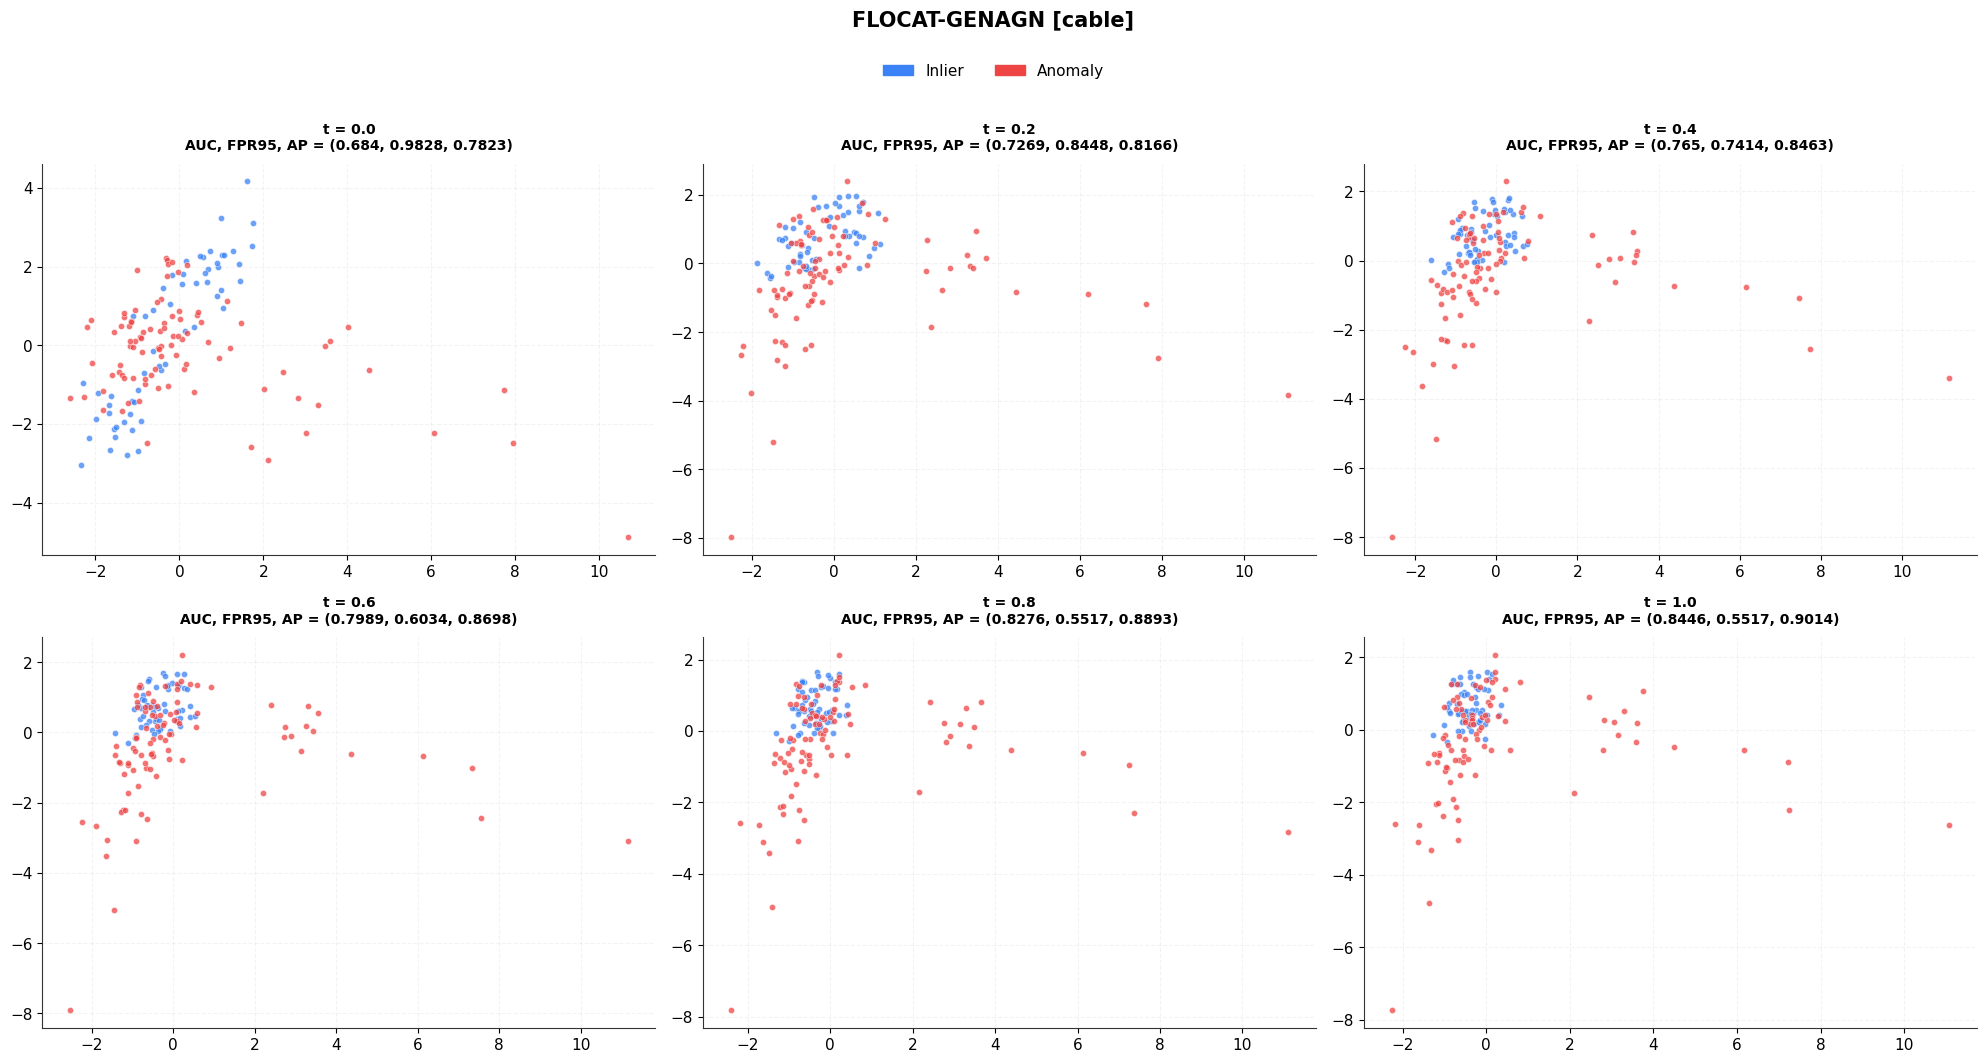

In [ ]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8,
})

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.patch.set_facecolor('white')
axes = axes.flatten()
steps = torch.linspace(0, 1, n_steps)

color_map = {0: '#3B82F6', 1: '#EF4444'}  
label_map = {0: 'Inlier', 1: 'Anomaly'}
y_test_arr = np.array(y_test)

for i in range(6):
    X_i = all_x_inter[i].detach().cpu().numpy()

    pca = PCA(n_components=2)
    X_i_pca = pca.fit_transform(X_i)

    ax = axes[i]

    for cls, color in color_map.items():
        mask = y_test_arr == cls
        ax.scatter(
            X_i_pca[mask, 0],
            X_i_pca[mask, 1],
            c=color,
            label=label_map[cls],
            alpha=0.75,
            s=20,
            edgecolors='white',
            linewidths=0.4,
        )

    ax.set_title(
        f"t = {steps[i]:.1f}\n"
        f"AUC, FPR95, AP = {metrics_inter[i]}",
        fontsize=10,
        fontweight='bold',
        pad=10
    )

    ax.grid(alpha=0.15, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

handles = [mpatches.Patch(color=c, label=label_map[k]) for k, c in color_map.items()]
fig.legend(handles=handles, loc='upper center', ncol=2, frameon=False,
           bbox_to_anchor=(0.5, 1.02), fontsize=11)

fig.suptitle(f"FLOCAT-GENAGN [{inlier_topic}]",
             fontsize=15, fontweight='bold', y=1.06)

plt.tight_layout(w_pad=1)
plt.show()

In [97]:
# !pip install open_clip_torch --break-system-packages

import open_clip

def build_clip_model(model_name="ViT-B-32", pretrained="openai", device="cpu"):
    model, _, preprocess = open_clip.create_model_and_transforms(
        model_name, pretrained=pretrained
    )
    model = model.to(device).eval()
    return model, preprocess

In [99]:
def extract_clip_embeddings(model, images):
    """Retourne un embedding global [B, D] par image (pas de grille spatiale)."""
    with torch.no_grad():
        embeddings = model.encode_image(images)  # [B, D]
    return embeddings.unsqueeze(1), (embeddings.shape[0], 1, 1)  # -> [B, 1, D] pour rester cohérent avec le format existant

def extract_clip_patch_embeddings(model, images):
    """Récupère les tokens patch du ViT de CLIP avant le pooling final."""
    with torch.no_grad():
        x = model.visual.conv1(images)  # patch embedding
        x = x.reshape(x.shape[0], x.shape[1], -1).permute(0, 2, 1)  # [B, N_patches, D]
        x = torch.cat([model.visual.class_embedding.expand(x.shape[0], 1, -1), x], dim=1)
        x = x + model.visual.positional_embedding
        x = model.visual.ln_pre(x)
        x = x.permute(1, 0, 2)
        x = model.visual.transformer(x)
        x = x.permute(1, 0, 2)
        patch_tokens = x[:, 1:, :]  # on retire le token [CLS]

    B, N, C = patch_tokens.shape
    H = W = int(N ** 0.5)  # grille carrée si N est un carré parfait
    return patch_tokens, (B, H, W)

In [103]:
from embed_images import MVTecAD
from torch.utils.data import Dataset, DataLoader

category = 'bottle'
root = '/home/2017025/ayouce01/FLOCAT-GENAGN/What-if-Flocat-were-truly-generic-and-agnostic/data/mv_tec_ad'

train_dataset = MVTecAD(root=root, category=category, split="train",
                            image_size=256)
test_dataset = MVTecAD(root=root, category=category, split="test",
                        image_size=256)

print(f"Train : {len(train_dataset)} images | Test : {len(test_dataset)} images")


loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
model, _ = build_clip_model(model_name="ViT-B-32", pretrained="openai", device=device)

all_embeddings, all_labels, all_defect_types, all_paths = [], [], [], []
grid_hw = None

for batch in loader:
    images = batch["image"].to(device)
    embeddings, (B, H, W) = extract_clip_patch_embeddings(model, images)
    grid_hw = (H, W)

    all_embeddings.append(embeddings.cpu())
    all_labels.extend(batch["label"].tolist())
    all_defect_types.extend(batch["defect_type"])
    all_paths.extend(batch["path"])

embeddings_tensor = torch.cat(all_embeddings, dim=0)


Train : 209 images | Test : 83 images


/home/2017025/ayouce01/.python3-3.12-torch251/site-packages/lib/python3.12/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


RuntimeError: The size of tensor a (65) must match the size of tensor b (50) at non-singleton dimension 1

In [3]:
import timm
import torch

def build_vit_model(model_name="vit_base_patch16_224", img_size=256, device="cpu"):
    """
    Charge un ViT pré-entraîné (supervisé, ImageNet) via timm.
    Modèles courants : vit_base_patch16_224, vit_small_patch16_224,
    vit_large_patch16_224, vit_base_patch32_224 (patchs plus gros, moins de tokens).
    """
    model = timm.create_model(model_name, pretrained=True, img_size=img_size).to(device).eval()
    return model


def extract_vit_patch_embeddings(model, images):
    """
    Récupère les tokens de patchs d'un ViT (timm), avant la tête de
    classification, en retirant le(s) token(s) spéciaux ([CLS], et
    éventuellement des registres selon l'architecture).

    Retourne des embeddings de forme [B, H*W, C], compatible avec le
    reste du pipeline (memory bank, coreset, etc.).
    """
    with torch.no_grad():
        x = model.patch_embed(images)          # [B, N_patches, C]
        x = model._pos_embed(x)                # ajoute [CLS] (+ registres) + positional embedding
        x = model.patch_drop(x)                # no-op en eval, présent selon versions timm
        x = model.norm_pre(x)

        for block in model.blocks:
            x = block(x)

        x = model.norm(x)                      # [B, 1+N_patches, C] (ou plus si tokens registre)

    num_prefix_tokens = getattr(model, "num_prefix_tokens", 1)  # 1 = juste [CLS], peut être >1 avec des registres
    patch_tokens = x[:, num_prefix_tokens:, :]  # on retire les tokens spéciaux -> [B, N_patches, C]

    B, N, C = patch_tokens.shape
    H = W = int(round(N ** 0.5))
    if H * W != N:
        raise ValueError(
            f"Le nombre de patchs ({N}) n'est pas un carré parfait : "
            f"grille spatiale non reconstructible proprement."
        )

    return patch_tokens, (B, H, W)


from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

def build_vit_transform(model):
    config = resolve_data_config({}, model=model)
    transform = create_transform(**config)
    return transform


from embed_images import MVTecAD
from torch.utils.data import Dataset, DataLoader

category = 'bottle'
root = '/home/2017025/ayouce01/FLOCAT-GENAGN/What-if-Flocat-were-truly-generic-and-agnostic/data/mv_tec_ad'

train_dataset = MVTecAD(root=root, category=category, split="train",
                            image_size=256)
test_dataset = MVTecAD(root=root, category=category, split="test",
                        image_size=256)

print(f"Train : {len(train_dataset)} images | Test : {len(test_dataset)} images")

device = "cuda" if torch.cuda.is_available() else "cpu"

model = build_vit_model("vit_base_patch16_224", img_size=224, device=device)
transform = build_vit_transform(model)

from torch.utils.data import DataLoader
loader = DataLoader(train_dataset, batch_size=16, shuffle=False)

for batch in loader:
    images = batch["image"].to(device)
    embeddings, (B, H, W) = extract_vit_patch_embeddings(model, images)
    print(images.shape)       # ex: [16, 3, 224, 224]
    print(embeddings.shape)   # ex: [16, 196, 768]  (14*14 patchs, dim 768)
    print(H, W)                # ex: 14 14
    break

Train : 209 images | Test : 83 images


AssertionError: Input height (256) doesn't match model (224).

torch.Size([3, 256, 256])

# Time Series